In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")


In [29]:
trades.columns = trades.columns.str.lower().str.strip()
list(trades.columns)







['account',
 'coin',
 'execution price',
 'size tokens',
 'size usd',
 'side',
 'timestamp ist',
 'start position',
 'direction',
 'closed pnl',
 'transaction hash',
 'order id',
 'crossed',
 'fee',
 'trade id',
 'timestamp']

In [30]:
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='ms')
trades['date'] = trades['timestamp'].dt.date


In [31]:
trades[['timestamp', 'date']].head()


,timestamp,date
0,2024-10-27 03:33:20,2024-10-27
1,2024-10-27 03:33:20,2024-10-27
2,2024-10-27 03:33:20,2024-10-27
3,2024-10-27 03:33:20,2024-10-27
4,2024-10-27 03:33:20,2024-10-27


In [32]:
trades['closed pnl'] = pd.to_numeric(trades['closed pnl'], errors='coerce')


In [33]:
trades = trades.dropna(subset=['closed pnl'])


In [34]:
trades = trades[trades['coin'].str.upper().isin(['BTC', 'BTCUSDT'])]


In [56]:
list(sentiment.columns)

['timestamp', 'value', 'classification', 'date']

In [36]:
sentiment.columns = sentiment.columns.str.lower().str.strip()


In [37]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


In [38]:
sentiment.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [39]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='inner'
)


In [57]:
merged.shape
merged['classification'].value_counts()


,count
classification,
Fear,16168
Greed,2299
Extreme Greed,1451
Neutral,217


In [58]:
import os

os.makedirs("csv_files", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


In [59]:
merged.to_csv("csv_files/merged_data.csv", index=False)

In [60]:
sentiment['classification'].value_counts()


,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


In [61]:
def simplify_sentiment(x):
    if 'fear' in x.lower():
        return 'Fear'
    elif 'greed' in x.lower():
        return 'Greed'
    else:
        return 'Neutral'

merged['sentiment_simple'] = merged['classification'].apply(simplify_sentiment)


In [62]:
merged['sentiment_simple'].value_counts()


,count
sentiment_simple,
Fear,16168
Greed,3750
Neutral,217


In [63]:
merged.groupby('sentiment_simple')['closed pnl'].describe()


,count,mean,std,min,25%,50%,75%,max
sentiment_simple,,,,,,,,
Fear,16168.0,34.148555,526.872664,-29370.119800,0.0,0.0,1.983594,19530.522500
Greed,3750.0,25.789912,167.264900,-2299.807104,0.0,0.0,0.372600,3154.574400
Neutral,217.0,48.319358,235.337266,-105.925096,0.0,0.0,2.572780,2239.485224


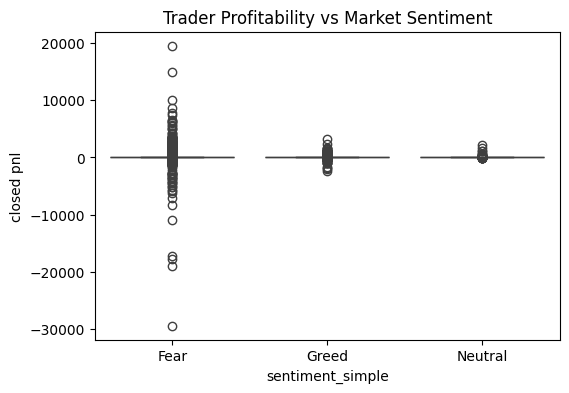

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='sentiment_simple',
    y='closed pnl',
    data=merged
)
plt.title("Trader Profitability vs Market Sentiment")
plt.savefig("outputs/pnl_vs_sentiment.png")
plt.show()


In [65]:
"""Although leverage is mentioned in the dataset description, the provided historical trade data does not contain an explicit leverage column. Therefore, here i have used trade size (USD)
and execution behavior  as proxies to analyze trader risk exposure."""
merged.groupby('sentiment_simple')['size usd'].describe()




,count,mean,std,min,25%,50%,75%,max
sentiment_simple,,,,,,,,
Fear,16168.0,21667.293166,77359.547606,0.79,474.8400,1972.065,17073.405,3509752.98
Greed,3750.0,13315.498517,21947.297928,0.43,499.0925,3624.895,19240.140,548305.49
Neutral,217.0,6340.492120,9288.833693,12.89,950.4200,2173.870,7697.790,48670.49


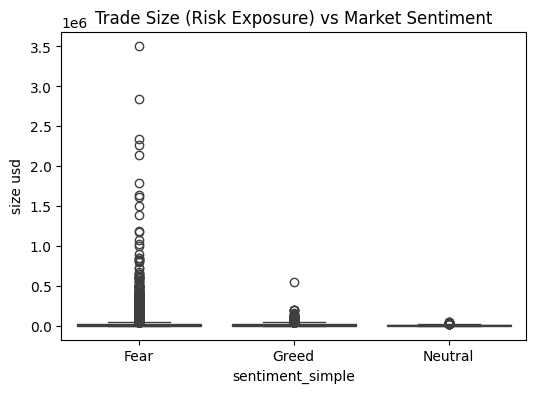

In [66]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='sentiment_simple',
    y='size usd',
    data=merged
)
plt.title("Trade Size (Risk Exposure) vs Market Sentiment")
plt.savefig("outputs/size_vs_sentiment.png")
plt.show()


In [67]:
pd.crosstab(
    merged['sentiment_simple'],
    merged['direction'],
    normalize='index'
)


direction,Close Long,Close Short,Long > Short,Open Long,Open Short,Short > Long
sentiment_simple,,,,,,
Fear,0.300223,0.096734,0.000309,0.456643,0.145782,0.000309
Greed,0.198667,0.232000,0.001067,0.282400,0.284533,0.001333
Neutral,0.322581,0.087558,0.000000,0.423963,0.165899,0.000000


In [68]:
merged.groupby('sentiment_simple')['fee'].mean()


,fee
sentiment_simple,
Fear,4.886150
Greed,3.767582
Neutral,2.218019


In [69]:
merged.to_csv("csv_files/merged_data_final.csv", index=False)
